In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path('..').parent.resolve().parent
DATA_DIR = BASE_DIR / 'data' / 'Gauss3.csv'

In [4]:
# data = np.loadtxt(DATA_DIR, skiprows=59, max_rows=11, usecols=(0, 1), unpack=True)
data = np.genfromtxt(DATA_DIR, skip_header=1)
data
X = data[:, [1]]
y = data[:, [0]]

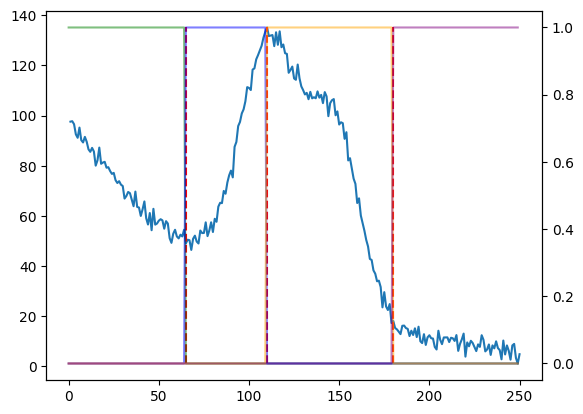

In [5]:
knots = [65, 110, 180]
B0 = np.zeros(len(X)).reshape(-1, 1); B0[X <= knots[0]] = 1
B1 = np.zeros(len(X)).reshape(-1, 1); B1[(X > knots[0]) & (X <= knots[1])] = 1
B2 = np.zeros(len(X)).reshape(-1, 1); B2[(X > knots[1]) & (X <= knots[2])] = 1
B3 = np.zeros(len(X)).reshape(-1, 1); B3[X > knots[2]] = 1

fig, axe = plt.subplots()

axe.plot(X,y)
axe.vlines(knots, ymin=y.min(), ymax=y.max(), colors='red', linestyles='dashed')

axe_t = axe.twinx()
axe_t.plot(B0, alpha=0.5, label='B0', color='green')
axe_t.plot(B1, alpha=0.5, label='B1', color='blue')
axe_t.plot(B2, alpha=0.5, label='B2', color='orange')
axe_t.plot(B3, alpha=0.5, label='B3', color='purple')

In [6]:
X.shape

(250, 1)

In [7]:
np.hstack(
    [
    np.ones(X.shape),
    X,

    *[np.maximum(X - kl, 0) for kl in knots],
    ]
)

array([[  1.,   1.,   0.,   0.,   0.],
       [  1.,   2.,   0.,   0.,   0.],
       [  1.,   3.,   0.,   0.,   0.],
       ...,
       [  1., 248., 183., 138.,  68.],
       [  1., 249., 184., 139.,  69.],
       [  1., 250., 185., 140.,  70.]], shape=(250, 5))

In [ ]:
class FuzzyRegressor():
    pass

## Modelo Polinomial de ordem k.

In [8]:
class PolynomialRegression:
    def __init__(self, degree):
        self.degree = degree
        self.coefficients = None

    def fit(self, X, y):

        X_poly = self._polymonil_features(X, self.degree)
        # self.coefficients = np.linalg.lstsq(X_poly, y, rcond=None)[0]
        self.coefficients = np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ y)

    def predict(self, X):
        X_poly = self._polymonil_features(X, self.degree)
        return X_poly @ self.coefficients

    def _polymonil_features(self, X, degree):
        m, n = X.shape
        X_poly = np.ones((m, 1))
        for i in range(n):
            x = X[:, i]
            X_poly = np.c_[X_poly, np.vander(x, degree +1, increasing=True)[:, 1:]]
        return X_poly

## Modelo Linear por partes

In [9]:
class PiecewiseLinearRegression:
    def __init__(self, n_pieces=None, knots=None):
        self.n_pieces = n_pieces
        self.knots = knots
        self.coefficients = None

    def fit(self, X, y):

        X_basis_expanded = self._basis_functions(X)

        self.coefficients = np.linalg.solve(X_basis_expanded.T @ X_basis_expanded, X_basis_expanded.T @ y)

    def predict(self, X):

        X_basis_expanded = self._basis_functions(X)

        return X_basis_expanded @ self.coefficients
    
    def _basis_functions(self, X):
        return np.hstack(
        [
        np.ones(X.shape),
        X,

        *[np.maximum(X - kl, 0) for kl in self.knots],
        ]
        )


## Modelo Fuzzy do tipo Mamdani

## Modelo Fuzzy do tipo Katagi-Sugeno

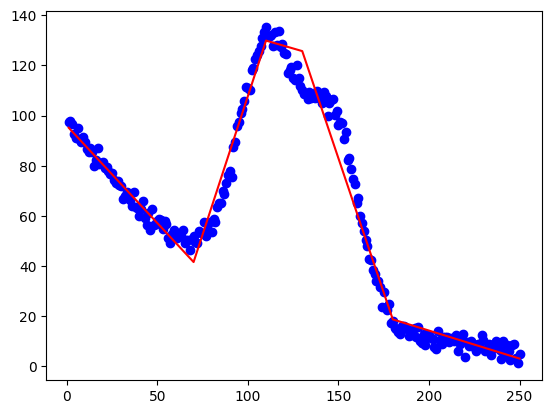

In [ ]:
pwreg = PiecewiseLinearRegression(knots=[70, 110, 130, 180])
pwreg.fit(X, y)
y_pred = pwreg.predict(X)

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_pred, color='red', label='Piecewise Linear Fit')

In [11]:
def predition(X, y, degree):
    
    reg = PolynomialRegression(degree)
    reg.fit(X, y)
    return reg.predict(X)

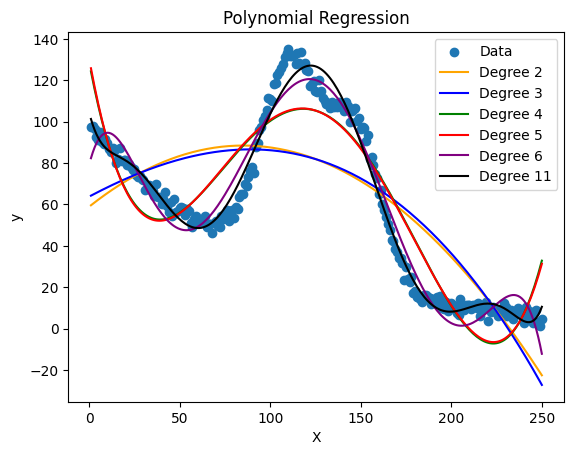

In [12]:
y_pred_2 = predition(X, y, degree=2)
y_pred_3 = predition(X, y, degree=3)
y_pred_4 = predition(X, y, degree=4)
y_pred_5 = predition(X, y, degree=5)
y_pred_6 = predition(X, y, degree=6)
y_pred_11 = predition(X, y, degree=8)
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred_2, label='Degree 2', color='orange')
plt.plot(X, y_pred_3, label='Degree 3', color='blue')
plt.plot(X, y_pred_4, label='Degree 4', color='green')
plt.plot(X, y_pred_5, label='Degree 5', color='red')
plt.plot(X, y_pred_6, label='Degree 6', color='purple')
plt.plot(X, y_pred_11, label='Degree 11', color='black')


plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()


## Carregando arquivo

In [16]:
# data = np.loadtxt(DATA_DIR, skiprows=59, max_rows=11, usecols=(0, 1), unpack=True)
data = np.genfromtxt(DATA_DIR, skip_header=1)
data
X = data[:, [1]]
y = data[:, [0]]

X.shape

(250, 1)